# Malaria Burden Prediction in Africa
## Comparing Traditional Machine Learning vs Deep Learning Approaches
 
**Dataset:** Africa Malaria Dataset (2007–2017) — 54 countries, 594 rows  
**Task:** Multi-class classification — predicting malaria burden level (Low / Medium / High)  
**Approaches:** Scikit-learn (Logistic Regression, Random Forest, XGBoost) vs TensorFlow (Sequential API, Functional API, tf.data pipeline)  
**Total Experiments:** 9

### Problem Statement

Malaria remains one of the leading causes of death in Sub-Saharan Africa. This project investigates whether a country's health infrastructure indicators  such as access to clean water, sanitation services, bed net usage, and population distribution  can be used to predict its malaria burden category. Understanding which features drive high malaria incidence can inform public health policy and resource allocation decisions across the continent.

## 1. Imports Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# Scikit-learn 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)

# XGBoost
from xgboost import XGBClassifier

# TensorFlow 
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'Random seed: {SEED}')


2026-02-24 15:41:58.887296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771947719.078893      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771947719.132290      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771947719.591819      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771947719.591859      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771947719.591862      55 computation_placer.cc:177] computation placer alr

All libraries imported successfully!
TensorFlow version: 2.19.0
Random seed: 42


## 2. Data Loading

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sherylotieno/malariadataset2/DatasetAfricaMalaria (1).csv')

print('DATASET SHAPE:', df.shape)
print(f'{df.shape[0]} rows x {df.shape[1]} columns')


DATASET SHAPE: (594, 27)
594 rows x 27 columns


In [3]:
print('FIRST 5 ROWS:')
display(df.head())


FIRST 5 ROWS:


,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


In [4]:
print('DATA TYPES:')
display(df.dtypes.to_frame(name='Data Type'))


DATA TYPES:


,Data Type
Country Name,object
Year,int64
Country Code,object
"Incidence of malaria (per 1,000 population at risk)",float64
Malaria cases reported,float64
Use of insecticide-treated bed nets (% of under-5 population),float64
Children with fever receiving antimalarial drugs (% of children under age 5 with fever),float64
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),float64
People using safely managed drinking water services (% of population),float64
"People using safely managed drinking water services, rural (% of rural population)",float64


In [5]:
print('BASIC STATISTICS:')
display(df.describe())


BASIC STATISTICS:


,Year,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)","People using safely managed drinking water services, urban (% of urban population)",People using safely managed sanitation services (% of population),...,Urban population (% of total population),Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude
count,594.000000,550.000000,5.500000e+02,132.000000,122.000000,106.000000,99.000000,88.000000,176.000000,132.000000,...,588.000000,588.000000,588.000000,566.000000,566.000000,588.000000,566.000000,566.000000,594.000000,594.000000
mean,2012.000000,190.087491,1.068330e+06,42.530303,30.201639,15.013958,33.478990,12.470568,51.549545,28.768939,...,43.164116,3.523061,65.994915,51.449576,84.268498,39.469796,28.077208,48.088375,2.828796,17.342546
std,3.164943,163.054527,2.192802e+06,20.157059,18.903198,12.389166,26.678321,10.078371,24.157416,18.631510,...,18.086118,1.456244,17.283361,18.927868,9.307285,26.304934,24.046725,21.802128,15.678226,20.041257
min,2007.000000,0.000000,0.000000e+00,1.000000,0.500000,0.000000,5.770000,0.930000,11.200000,6.370000,...,9.860000,-4.650000,28.960000,17.050000,52.010000,4.990000,1.890000,12.580000,-30.559482,-24.013197
25%,2009.000000,30.857500,2.211750e+03,26.675000,17.275000,5.763285,8.975000,4.185000,34.125000,16.532500,...,28.795000,2.512500,52.375000,37.075000,78.080000,18.197500,8.842500,30.775000,-6.369028,0.824782
50%,2012.000000,174.775000,1.130260e+05,42.900000,29.300000,11.500000,28.390000,10.675000,51.365000,25.410000,...,41.560000,3.730000,64.470000,50.435000,85.420000,32.555000,18.815000,44.695000,6.744051,18.611308
75%,2015.000000,347.637500,1.154808e+06,56.325000,42.625000,21.850000,43.890000,16.887500,70.747500,35.725000,...,56.945000,4.450000,79.165000,62.245000,90.082500,54.810000,38.082500,58.845000,12.862807,31.465866
max,2017.000000,585.540000,1.682113e+07,95.500000,76.900000,59.600000,92.660000,39.930000,89.540000,78.120000,...,88.980000,7.400000,99.870000,99.830000,99.920000,100.000000,95.180000,98.300000,33.886917,57.552152


MISSING VALUES PER COLUMN:


,Missing Count,Missing %
"People using safely managed drinking water services, rural (% of rural population)",506,85.19
People using safely managed drinking water services (% of population),495,83.33
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),488,82.15
"People using safely managed sanitation services, rural (% of rural population)",484,81.48
Children with fever receiving antimalarial drugs (% of children under age 5 with fever),472,79.46
People using safely managed sanitation services (% of population),462,77.78
Use of insecticide-treated bed nets (% of under-5 population),462,77.78
"People using safely managed sanitation services, urban (% of urban population)",462,77.78
"People using safely managed drinking water services, urban (% of urban population)",418,70.37
Malaria cases reported,44,7.41


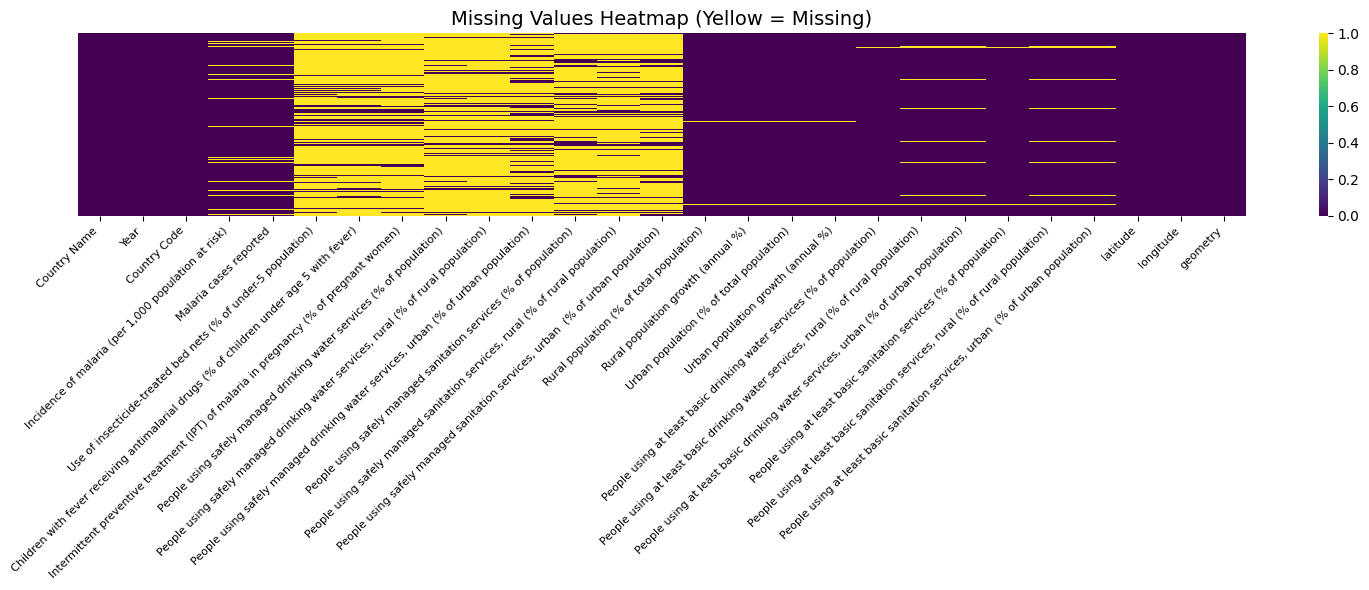

In [6]:
# Missing value analysis
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print('MISSING VALUES PER COLUMN:')
display(missing_df)

# Heatmap to visualise where the gaps are across the dataset
plt.figure(figsize=(16, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
print('Duplicate Rows:', df.duplicated().sum())
print('Unique Countries:', df['Country Name'].nunique())
print('Year Range:', df['Year'].min(), '-', df['Year'].max())
print('\nCountries covered:')
print(sorted(df['Country Name'].unique().tolist()))


Duplicate Rows: 0
Unique Countries: 54
Year Range: 2007 - 2017

Countries covered:
['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Djibouti', 'Egypt, Arab Rep.', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']


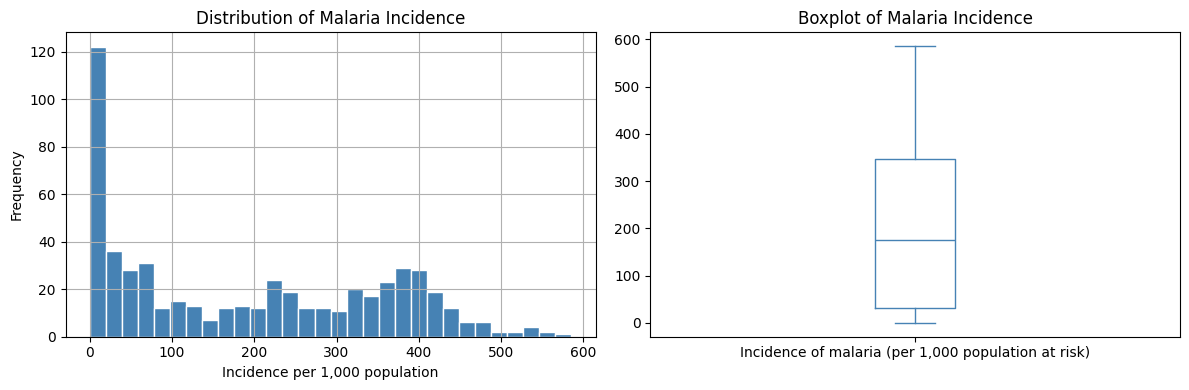

In [8]:
# Distribution and spread of malaria incidence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Incidence of malaria (per 1,000 population at risk)'].dropna().hist(
    bins=30, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Malaria Incidence')
axes[0].set_xlabel('Incidence per 1,000 population')
axes[0].set_ylabel('Frequency')
df['Incidence of malaria (per 1,000 population at risk)'].dropna().plot(
    kind='box', ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Malaria Incidence')
plt.tight_layout()
plt.show()


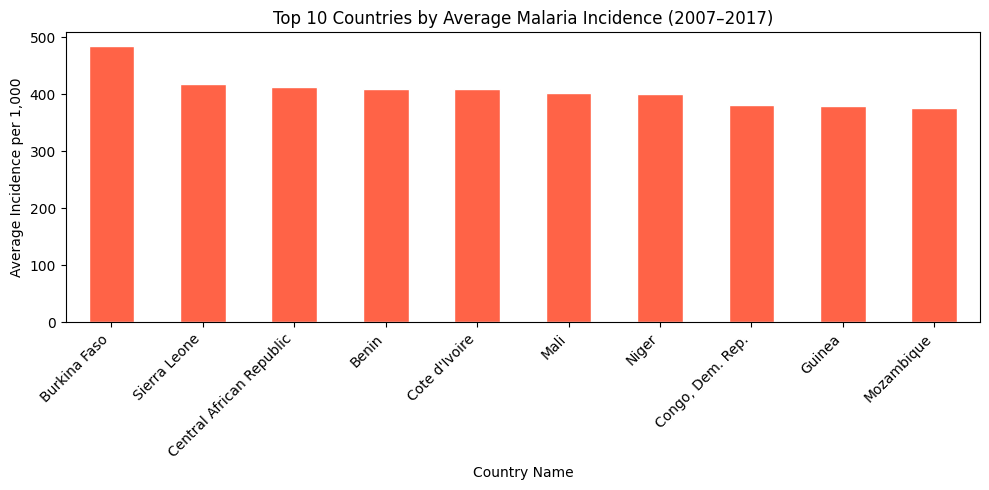

In [9]:
# Top 10 countries by average malaria incidence
top_countries = (df.groupby('Country Name')['Incidence of malaria (per 1,000 population at risk)']
                 .mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 10 Countries by Average Malaria Incidence (2007–2017)')
plt.ylabel('Average Incidence per 1,000')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


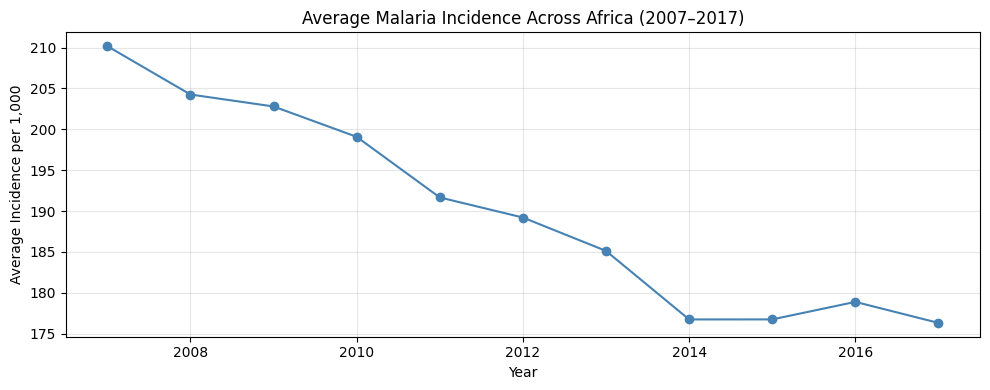

In [10]:
# Average malaria incidence trend over years
yearly = df.groupby('Year')['Incidence of malaria (per 1,000 population at risk)'].mean()
plt.figure(figsize=(10, 4))
yearly.plot(marker='o', color='steelblue')
plt.title('Average Malaria Incidence Across Africa (2007–2017)')
plt.ylabel('Average Incidence per 1,000')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


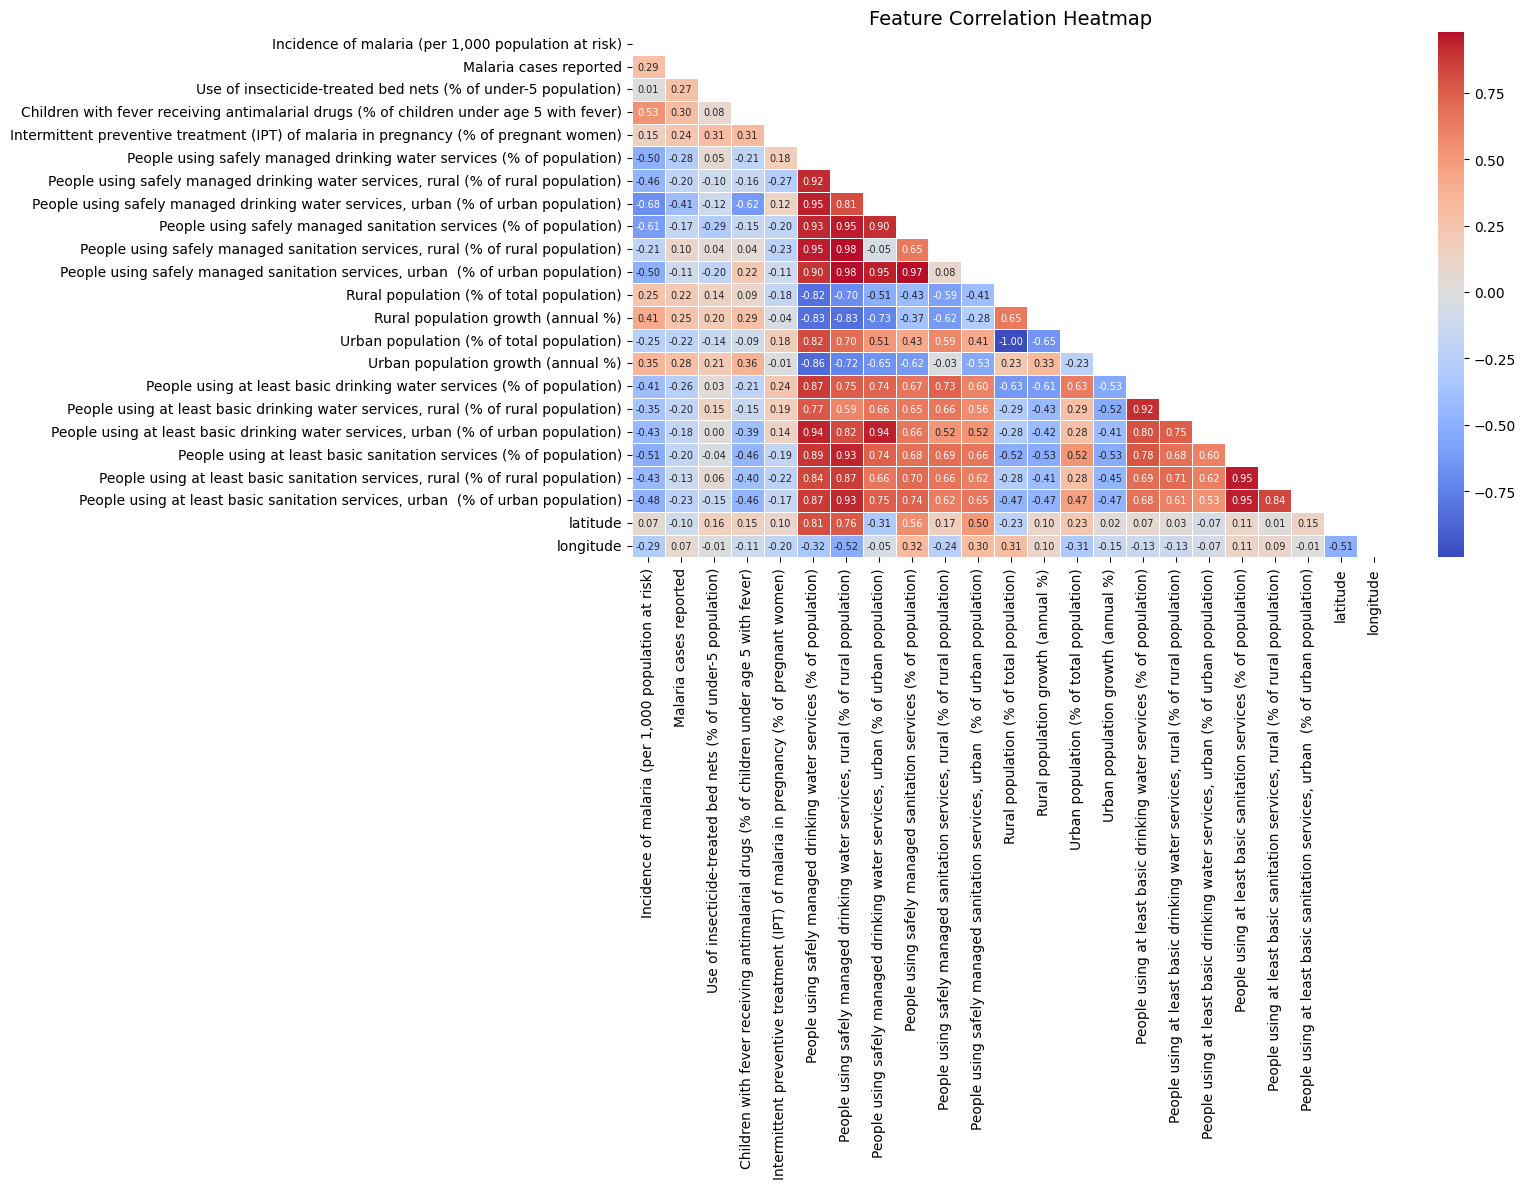

In [11]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include='float64')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing and Cleaning

In [12]:
# Drop redundant columns
# 'geometry' is a string duplicate of latitude and longitude (e.g. POINT(28.03 1.65))
# 'Country Code' carries the same information as Country Name in shorter form
df = df.drop(columns=['geometry', 'Country Code'])
print('Dropped: geometry, Country Code')

# Fill missing values with per country mean
numeric_cols = df.select_dtypes(include='float64').columns.tolist()
df[numeric_cols] = df.groupby('Country Name')[numeric_cols].transform(
    lambda x: x.fillna(x.mean())
)

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print('Missing values after cleaning:', df.isnull().sum().sum())
print('Shape after cleaning:', df.shape)


Dropped: geometry, Country Code
Missing values after cleaning: 0
Shape after cleaning: (594, 25)


## 4. Feature Engineering and Encoding

Class distribution:
Malaria_Burden
Low       188
Medium    185
High      179
Name: count, dtype: int64


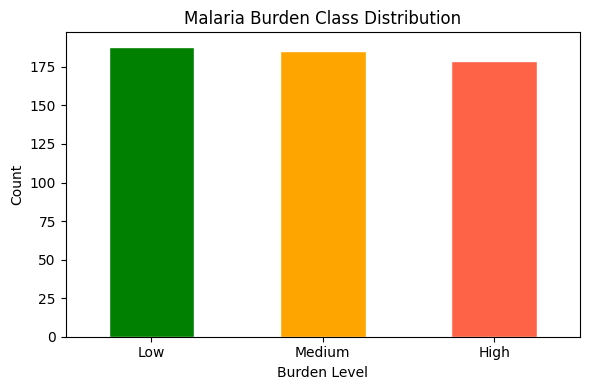

In [13]:

# Bin malaria incidence into 3 burden categories
# Bin boundaries are chosen based on the data distribution observed in EDA:
#   Low    : 0   to 100  — low transmission environments
#   Medium : 100 to 300  — moderate transmission
#   High   : 300+        — high burden

df['Incidence of malaria (per 1,000 population at risk)'] = df[
    'Incidence of malaria (per 1,000 population at risk)'
].fillna(df['Incidence of malaria (per 1,000 population at risk)'].mean())

bins   = [0, 100, 300, df['Incidence of malaria (per 1,000 population at risk)'].max() + 1]
labels = ['Low', 'Medium', 'High']

df['Malaria_Burden'] = pd.cut(
    df['Incidence of malaria (per 1,000 population at risk)'],
    bins=bins, labels=labels
)

print('Class distribution:')
print(df['Malaria_Burden'].value_counts())

plt.figure(figsize=(6, 4))
df['Malaria_Burden'].value_counts().reindex(['Low', 'Medium', 'High']).plot(
    kind='bar', color=['green', 'orange', 'tomato'], edgecolor='white')
plt.title('Malaria Burden Class Distribution')
plt.xlabel('Burden Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [14]:
# Feature 1: Water-Sanitation Composite Score
# Average of basic water and sanitation access 
# health infrastructure quality in a single value.
df['Water_Sanitation_Score'] = df[[
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]].mean(axis=1)

# Feature 2: Urban-Rural Water Gap
df['Urban_Rural_Water_Gap'] = (
    df['People using at least basic drinking water services, urban (% of urban population)'] -
    df['People using at least basic drinking water services, rural (% of rural population)']
)

print('Engineered features added:')
print('  - Water_Sanitation_Score')
print('  - Urban_Rural_Water_Gap')


Engineered features added:
  - Water_Sanitation_Score
  - Urban_Rural_Water_Gap


In [15]:

# Each country is encoded as its mean malaria incidence value.
country_mean = df.groupby('Country Name')['Incidence of malaria (per 1,000 population at risk)'].mean()
df['Country_Encoded'] = df['Country Name'].map(country_mean)
print('Country Name target-encoded successfully.')


Country Name target-encoded successfully.


In [16]:

#   High = 0, Low = 1, Medium = 2
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Malaria_Burden'].astype(str))

classes = [c for c in list(le.classes_) if c != 'nan']
# Re-encode using  clean classes
df = df[df['Malaria_Burden'].astype(str) != 'nan'].copy()
le2 = LabelEncoder()
df['Target'] = le2.fit_transform(df['Malaria_Burden'].astype(str))
classes = list(le2.classes_)

print('Class mapping:', dict(zip(le2.classes_, le2.transform(le2.classes_))))
print('Classes:', classes)
print('Total rows:', len(df))


Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Classes: ['High', 'Low', 'Medium']
Total rows: 552


In [17]:

drop_cols = [
    'Country Name',
    'Malaria_Burden',
    'Incidence of malaria (per 1,000 population at risk)',
    'Malaria cases reported'
]

df = df.reset_index(drop=True)

X = df.drop(columns=drop_cols + ['Target'])
y = df['Target']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Target unique values:', sorted(y.unique().tolist()))
print('\nFeature columns:')
for col in X.columns:
    print(' -', col)


Features shape: (552, 25)
Target shape: (552,)
Target unique values: [0, 1, 2]

Feature columns:
 - Year
 - Use of insecticide-treated bed nets (% of under-5 population)
 - Children with fever receiving antimalarial drugs (% of children under age 5 with fever)
 - Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)
 - People using safely managed drinking water services (% of population)
 - People using safely managed drinking water services, rural (% of rural population)
 - People using safely managed drinking water services, urban (% of urban population)
 - People using safely managed sanitation services (% of population)
 - People using safely managed sanitation services, rural (% of rural population)
 - People using safely managed sanitation services, urban  (% of urban population)
 - Rural population (% of total population)
 - Rural population growth (annual %)
 - Urban population (% of total population)
 - Urban population growth (annual %)
 - Peop

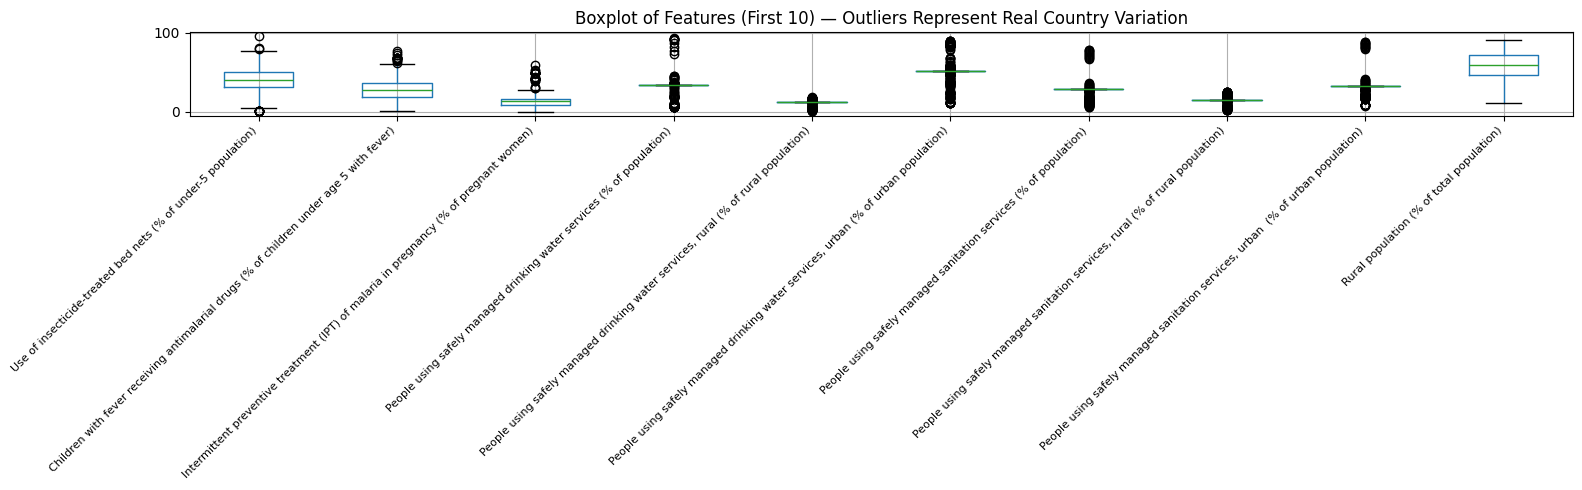

In [18]:
# Outlier Analysis 
fig, ax = plt.subplots(figsize=(16, 5))
X.select_dtypes(include='float64').iloc[:, :10].boxplot(ax=ax)
plt.title('Boxplot of Features (First 10) — Outliers Represent Real Country Variation')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print(f'Train size     : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation size: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test size      : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)')


Train size     : 352 rows (63.8%)
Validation size: 89 rows (16.1%)
Test size      : 111 rows (20.1%)


In [20]:
# Standardization 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Features standardized successfully.')
print('Scaler fitted on training data only — no data leakage.')


Features standardized successfully.
Scaler fitted on training data only — no data leakage.


In [21]:
def plot_confusion_matrix(y_true, y_pred, title, classes):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_curves(y_true, y_prob, classes, title):
    """Plot one-vs-rest ROC curves for each class."""
    y_true_bin = to_categorical(y_true, num_classes=len(classes))
    plt.figure(figsize=(8, 5))
    colors = ['steelblue', 'tomato', 'green']
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=color, label=f'{cls} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_learning_curve(model, X, y, title):
    """Plot training vs validation accuracy learning curve for sklearn models."""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=SEED
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Accuracy')
    plt.plot(train_sizes, val_mean,   'o-', color='tomato',    label='Validation Accuracy')
    plt.fill_between(train_sizes,
                     train_mean - train_scores.std(axis=1),
                     train_mean + train_scores.std(axis=1),
                     alpha=0.1, color='steelblue')
    plt.fill_between(train_sizes,
                     val_mean - val_scores.std(axis=1),
                     val_mean + val_scores.std(axis=1),
                     alpha=0.1, color='tomato')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_dl_history(history, title):
    """Plot training and validation loss and accuracy curves for DL models."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_model(name, y_true, y_pred, y_prob, classes):
    """Print accuracy, ROC-AUC, and full classification report. Return metrics."""
    acc = accuracy_score(y_true, y_pred)
    y_true_bin = to_categorical(y_true, num_classes=len(classes))
    auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
    print(f"\n{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    print(f'  Accuracy : {acc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=classes))
    return acc, auc


# Results tracker
results = []

n_features  = X_train_scaled.shape[1]
n_classes   = len(classes)
y_train_cat = to_categorical(y_train, n_classes)
y_val_cat   = to_categorical(y_val,   n_classes)
y_test_cat  = to_categorical(y_test,  n_classes)

print('Helper functions defined successfully.')
print(f'n_features = {n_features}')
print(f'n_classes  = {n_classes}')
print(f'classes    = {classes}')
print(f'Train/Val/Test: {len(y_train)}/{len(y_val)}/{len(y_test)}')


Helper functions defined successfully.
n_features = 25
n_classes  = 3
classes    = ['High', 'Low', 'Medium']
Train/Val/Test: 352/89/111


### Experiment 1: Logistic Regression — Baseline (L2 Regularization)


  Experiment 1: Logistic Regression (Baseline)
  Accuracy : 0.9009
  ROC-AUC  : 0.9890

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.92      0.93        36
         Low       0.94      0.89      0.92        38
      Medium       0.82      0.89      0.86        37

    accuracy                           0.90       111
   macro avg       0.90      0.90      0.90       111
weighted avg       0.90      0.90      0.90       111



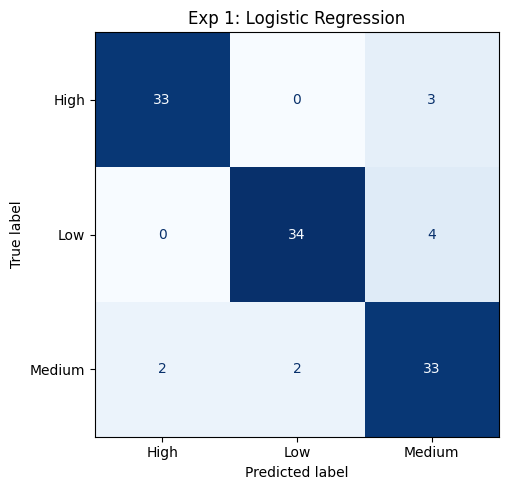

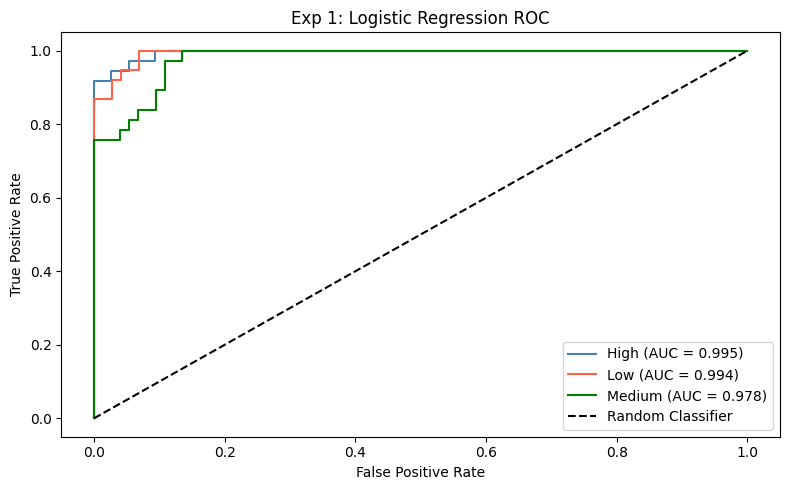

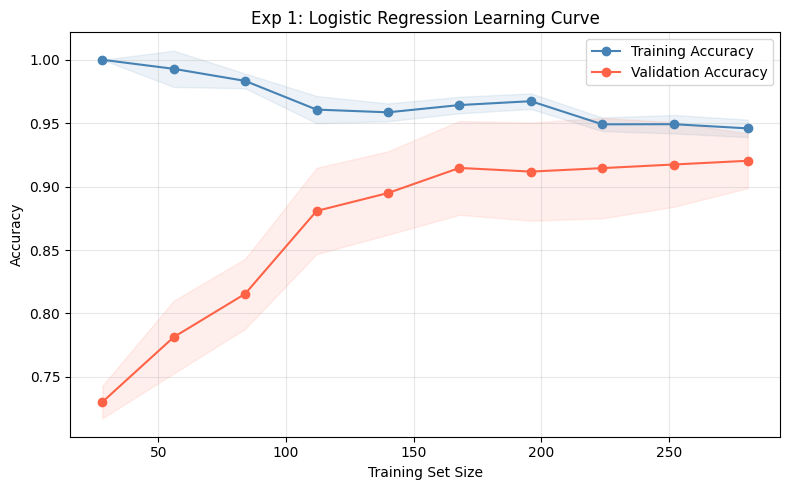

In [22]:
log_reg = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                              random_state=SEED, max_iter=1000,
                              multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)

acc_lr, auc_lr = evaluate_model('Experiment 1: Logistic Regression (Baseline)',
                                 y_test, y_pred_lr, y_prob_lr, classes)

plot_confusion_matrix(y_test, y_pred_lr, 'Exp 1: Logistic Regression', classes)
plot_roc_curves(y_test, y_prob_lr, classes, 'Exp 1: Logistic Regression ROC')
plot_learning_curve(log_reg, X_train_scaled, y_train, 'Exp 1: Logistic Regression Learning Curve')

results.append({
    'Experiment': 'Exp 1: Logistic Regression (L2)',
    'Type': 'Traditional ML',
    'Key Settings': 'penalty=L2, C=1.0, solver=lbfgs, multinomial',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_lr,
    'ROC-AUC': auc_lr
})


**Results Interpretation (Exp 1):**

Accuracy: 0.9009 | ROC-AUC: 0.9890

Logistic Regression achieves 90% accuracy which is strong for a linear model.

### Experiment 2: Logistic Regression — L1 Regularization


  Experiment 2: Logistic Regression (L1)
  Accuracy : 0.9099
  ROC-AUC  : 0.9909

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.94      0.94        36
         Low       0.94      0.89      0.92        38
      Medium       0.85      0.89      0.87        37

    accuracy                           0.91       111
   macro avg       0.91      0.91      0.91       111
weighted avg       0.91      0.91      0.91       111


Features zeroed out by L1: 7 out of 25


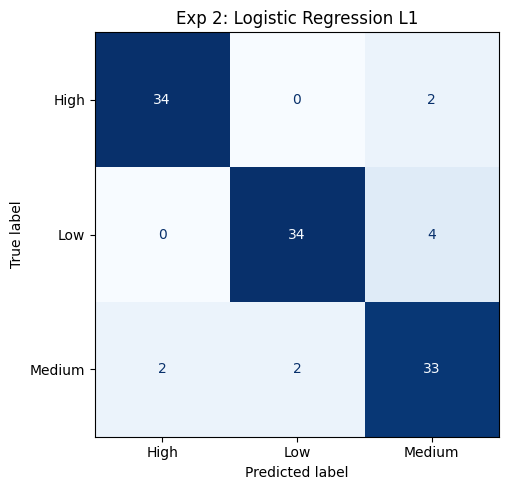

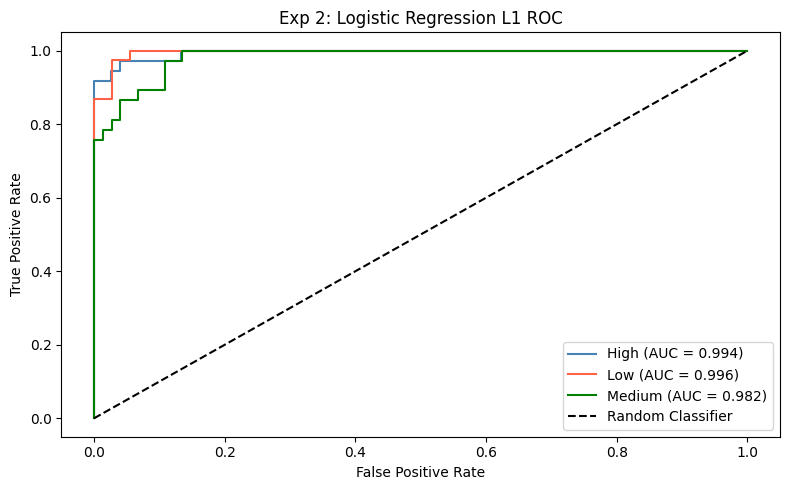

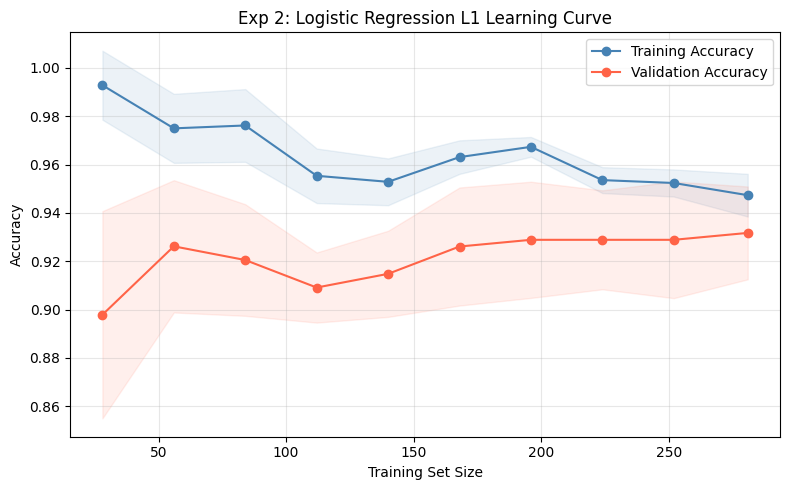

In [23]:
log_reg_l1 = LogisticRegression(penalty='l1', solver='saga', C=1.0,
                                 random_state=SEED, max_iter=1000,
                                 multi_class='multinomial')
log_reg_l1.fit(X_train_scaled, y_train)

y_pred_lr1 = log_reg_l1.predict(X_test_scaled)
y_prob_lr1 = log_reg_l1.predict_proba(X_test_scaled)

acc_lr1, auc_lr1 = evaluate_model('Experiment 2: Logistic Regression (L1)',
                                   y_test, y_pred_lr1, y_prob_lr1, classes)

zeroed = (log_reg_l1.coef_ == 0).all(axis=0).sum()
print(f'\nFeatures zeroed out by L1: {zeroed} out of {n_features}')

plot_confusion_matrix(y_test, y_pred_lr1, 'Exp 2: Logistic Regression L1', classes)
plot_roc_curves(y_test, y_prob_lr1, classes, 'Exp 2: Logistic Regression L1 ROC')
plot_learning_curve(log_reg_l1, X_train_scaled, y_train, 'Exp 2: Logistic Regression L1 Learning Curve')

results.append({
    'Experiment': 'Exp 2: Logistic Regression (L1)',
    'Type': 'Traditional ML',
    'Key Settings': 'penalty=L1, C=1.0, solver=saga, multinomial',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_lr1,
    'ROC-AUC': auc_lr1
})


### Experiment 3: Random Forest — Default Settings


  Experiment 3: Random Forest (Default)
  Accuracy : 0.9279
  ROC-AUC  : 0.9946

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.94      0.96        36
         Low       0.95      0.92      0.93        38
      Medium       0.87      0.92      0.89        37

    accuracy                           0.93       111
   macro avg       0.93      0.93      0.93       111
weighted avg       0.93      0.93      0.93       111



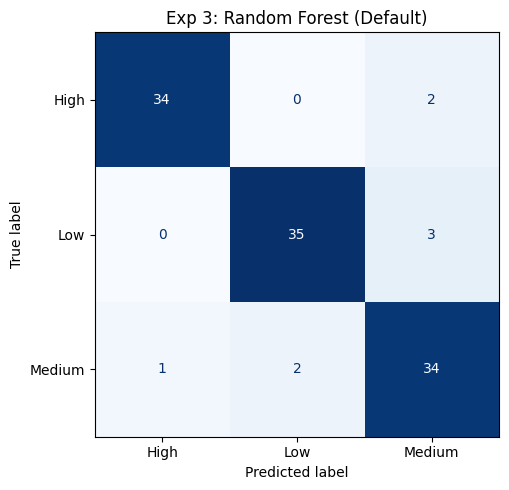

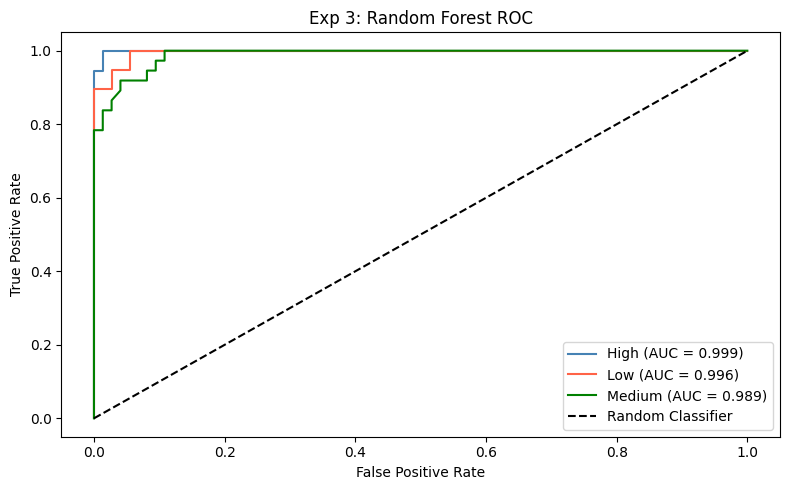

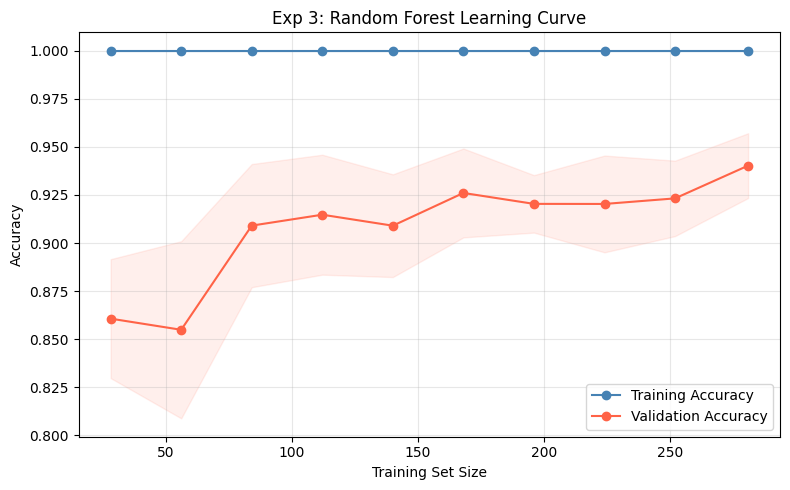

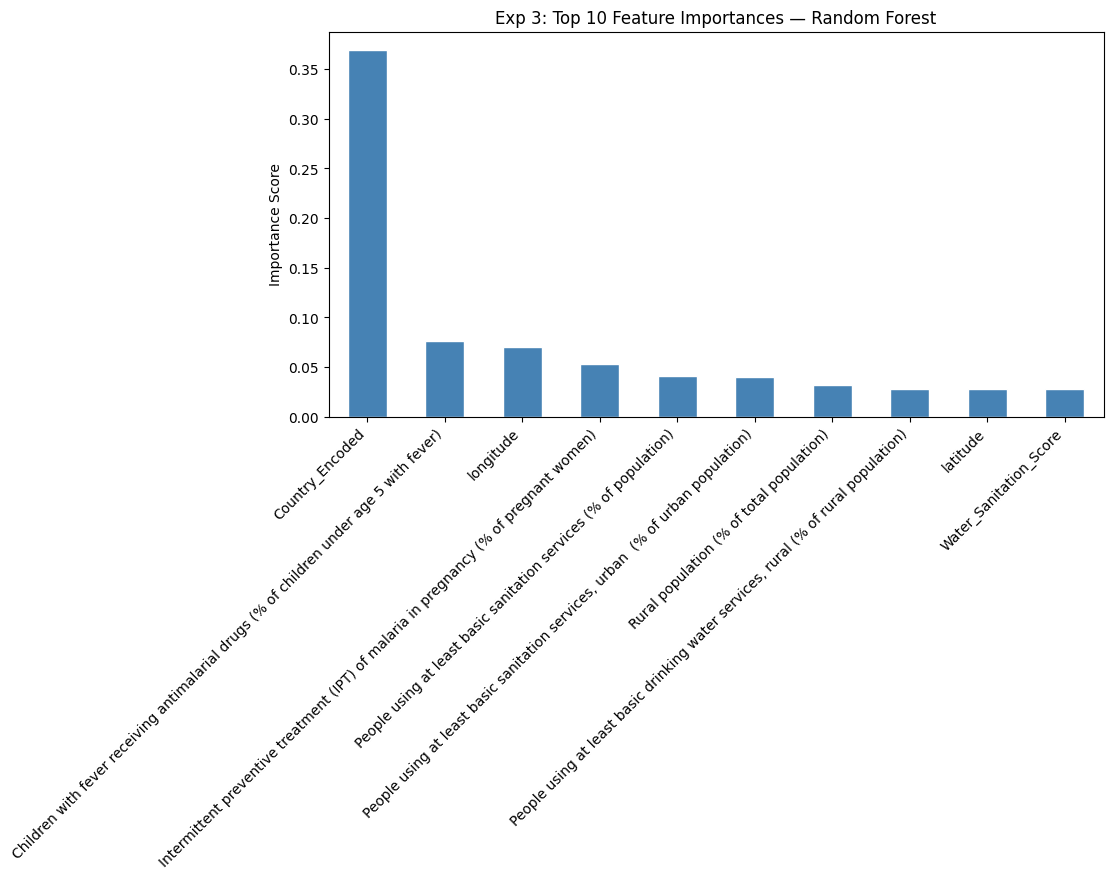

In [24]:
rf = RandomForestClassifier(random_state=SEED)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)

acc_rf, auc_rf = evaluate_model('Experiment 3: Random Forest (Default)',
                                 y_test, y_pred_rf, y_prob_rf, classes)

plot_confusion_matrix(y_test, y_pred_rf, 'Exp 3: Random Forest (Default)', classes)
plot_roc_curves(y_test, y_prob_rf, classes, 'Exp 3: Random Forest ROC')
plot_learning_curve(rf, X_train_scaled, y_train, 'Exp 3: Random Forest Learning Curve')

# Feature importance — which features does the model rely on most?
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Exp 3: Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

results.append({
    'Experiment': 'Exp 3: Random Forest (Default)',
    'Type': 'Traditional ML',
    'Key Settings': 'n_estimators=100, max_depth=None, default settings',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_rf,
    'ROC-AUC': auc_rf
})


### Experiment 4: Random Forest - Tuned Hyperparameters

**Rationale:** Based on the mild overfitting observed in Exp 3, I introduce constraints:
- n_estimators=300: more trees for more stable predictions
- max_depth=10: prevents trees from growing too deep and memorising training data
- min_samples_split=5: requires at least 5 samples to split a node
- min_samples_leaf=2: requires at least 2 samples at each leaf node

These constraints add regularization to the ensemble.


  Experiment 4: Random Forest (Tuned)
  Accuracy : 0.9189
  ROC-AUC  : 0.9929

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.94      0.96        36
         Low       0.92      0.92      0.92        38
      Medium       0.87      0.89      0.88        37

    accuracy                           0.92       111
   macro avg       0.92      0.92      0.92       111
weighted avg       0.92      0.92      0.92       111



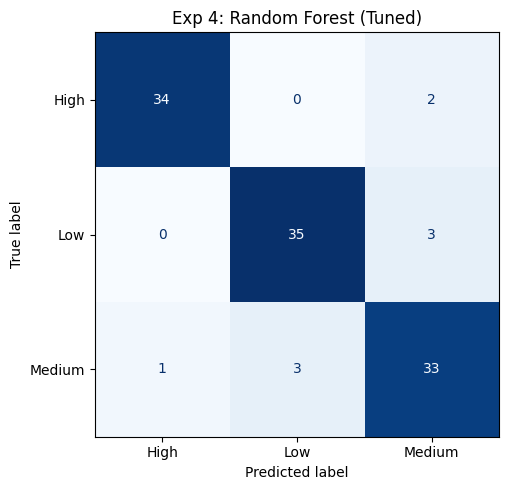

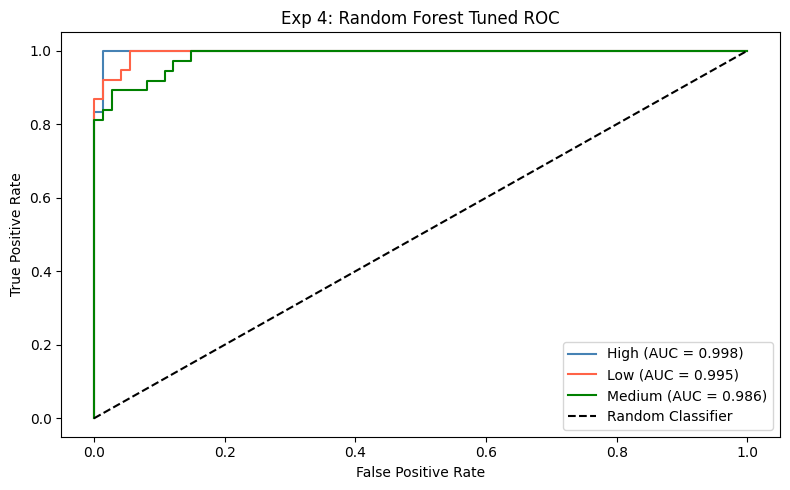

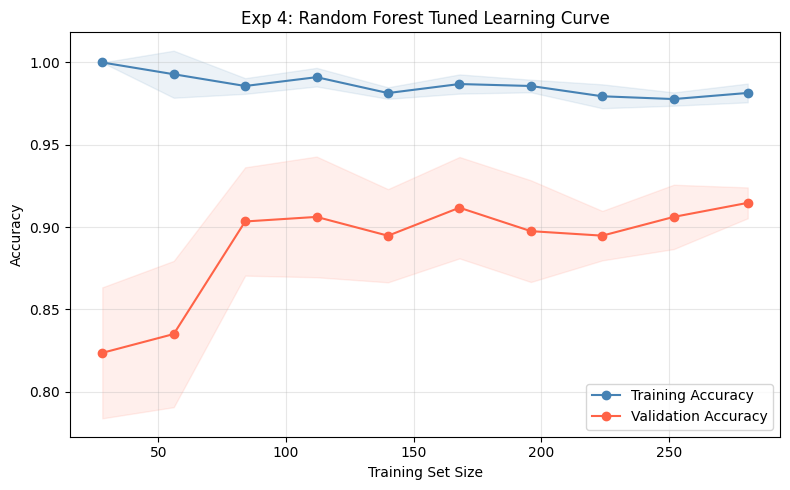

In [25]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED
)
rf_tuned.fit(X_train_scaled, y_train)

y_pred_rft = rf_tuned.predict(X_test_scaled)
y_prob_rft = rf_tuned.predict_proba(X_test_scaled)

acc_rft, auc_rft = evaluate_model('Experiment 4: Random Forest (Tuned)',
                                   y_test, y_pred_rft, y_prob_rft, classes)

plot_confusion_matrix(y_test, y_pred_rft, 'Exp 4: Random Forest (Tuned)', classes)
plot_roc_curves(y_test, y_prob_rft, classes, 'Exp 4: Random Forest Tuned ROC')
plot_learning_curve(rf_tuned, X_train_scaled, y_train, 'Exp 4: Random Forest Tuned Learning Curve')

results.append({
    'Experiment': 'Exp 4: Random Forest (Tuned)',
    'Type': 'Traditional ML',
    'Key Settings': 'n_estimators=300, max_depth=10, min_samples_split=5, min_samples_leaf=2',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_rft,
    'ROC-AUC': auc_rft
})


### Experiment 5: XGBoost


  Experiment 5: XGBoost
  Accuracy : 0.9369
  ROC-AUC  : 0.9949

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.94      0.94        36
         Low       1.00      0.92      0.96        38
      Medium       0.88      0.95      0.91        37

    accuracy                           0.94       111
   macro avg       0.94      0.94      0.94       111
weighted avg       0.94      0.94      0.94       111



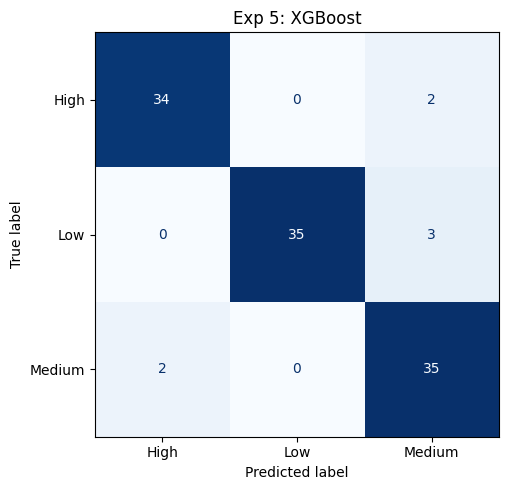

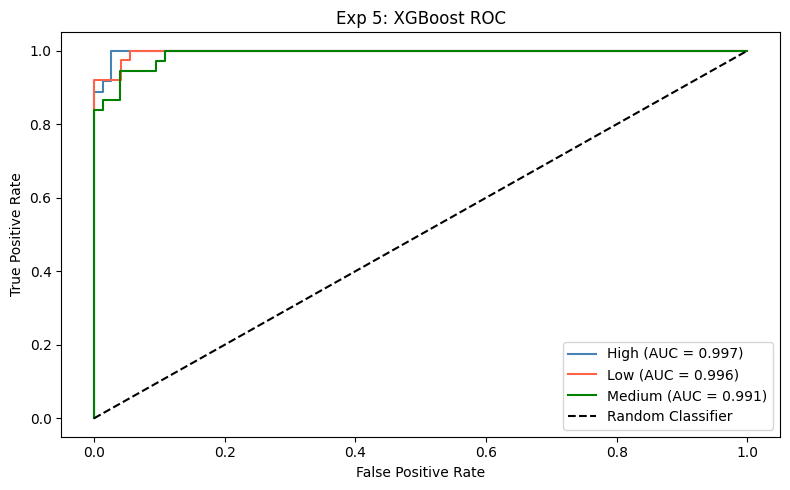

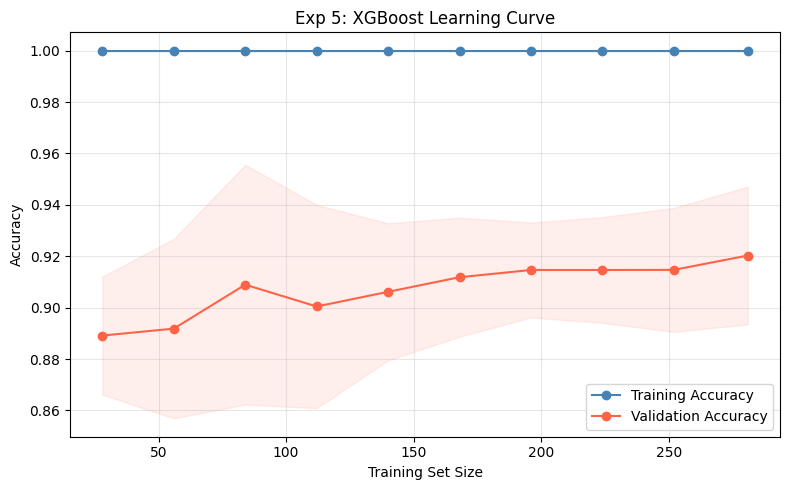

In [26]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=SEED,
    verbosity=0
)
xgb.fit(X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)],
        verbose=False)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)

acc_xgb, auc_xgb = evaluate_model('Experiment 5: XGBoost',
                                   y_test, y_pred_xgb, y_prob_xgb, classes)

plot_confusion_matrix(y_test, y_pred_xgb, 'Exp 5: XGBoost', classes)
plot_roc_curves(y_test, y_prob_xgb, classes, 'Exp 5: XGBoost ROC')
plot_learning_curve(xgb, X_train_scaled, y_train, 'Exp 5: XGBoost Learning Curve')

results.append({
    'Experiment': 'Exp 5: XGBoost',
    'Type': 'Traditional ML',
    'Key Settings': 'n_estimators=200, learning_rate=0.05, max_depth=6',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_xgb,
    'ROC-AUC': auc_xgb
})


### Experiment 6: Simple Sequential Neural Network — DL Baseline

Two hidden dense layers with ReLU activation and no regularization. 

I0000 00:00:1771947795.137824      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,843 (15.01 KB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1771947797.273741     112 service.cc:152] XLA service 0x7a11f0008750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771947797.273775     112 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771947797.515197     112 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771947798.193851     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

  Experiment 6: Simple Sequential DL
  Accuracy : 0.9279
  ROC-AUC  : 0.9945

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.94      0.97        36
         Low       0.94      0.89      0.92        38
      Medium       0.85      0.95      0.90        37

    accuracy                           0.93       111
   macro avg       0.93      0.93      0.93       111
weighted avg       0.93      0.93      0.93       111



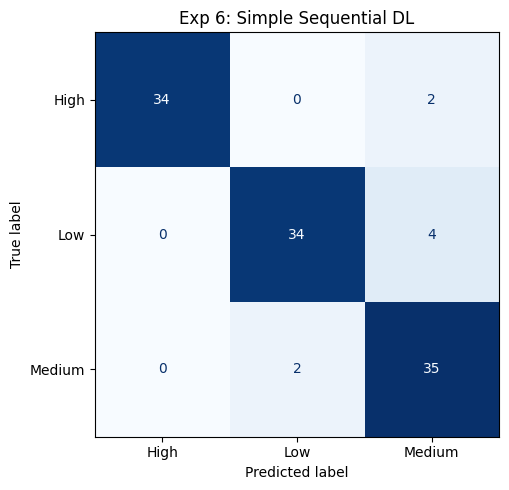

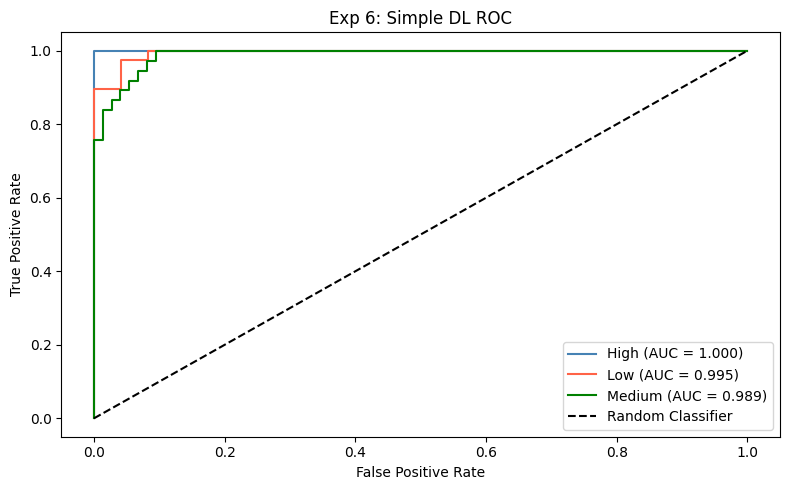

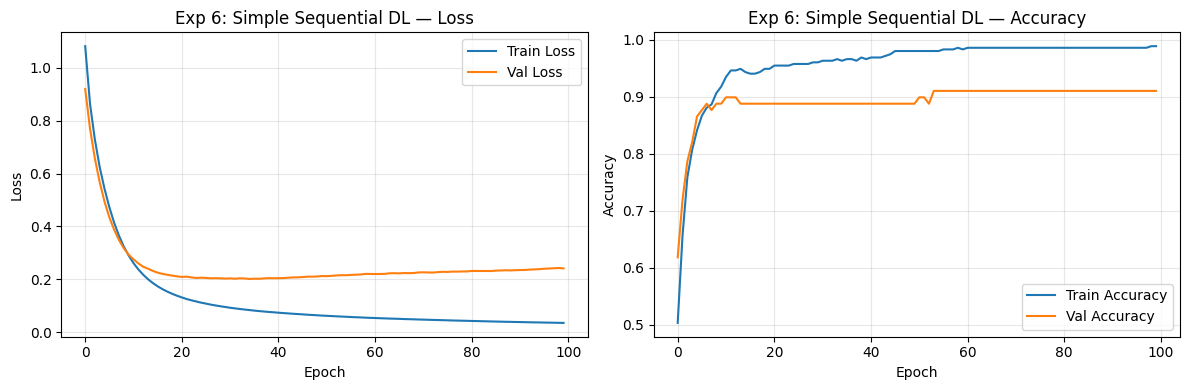

In [27]:
model_simple = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model_simple.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
model_simple.summary()

history_simple = model_simple.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100, batch_size=32, verbose=0
)

y_prob_s = model_simple.predict(X_test_scaled)
y_pred_s = np.argmax(y_prob_s, axis=1)

acc_s, auc_s = evaluate_model('Experiment 6: Simple Sequential DL',
                               y_test, y_pred_s, y_prob_s, classes)

plot_confusion_matrix(y_test, y_pred_s, 'Exp 6: Simple Sequential DL', classes)
plot_roc_curves(y_test, y_prob_s, classes, 'Exp 6: Simple DL ROC')
plot_dl_history(history_simple, 'Exp 6: Simple Sequential DL')

results.append({
    'Experiment': 'Exp 6: Simple Sequential DL',
    'Type': 'Deep Learning',
    'Key Settings': 'Dense(64)->Dense(32), Adam, 100 epochs, no regularization',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_s,
    'ROC-AUC': auc_s
})


### Experiment 7: Sequential DL with Dropout, Batch Normalization, and Early Stopping

Address the overfitting from Exp 6 with three techniques:
- **Batch Normalization:** Normalizes each layer's input, stabilizing training and reducing internal covariate shift
- **Dropout (0.3):** Randomly disables 30% of neurons per training step, preventing over reliance on any single neuron
- **Early Stopping (patience=15):** Stops training when val_loss stops improving for 15 epochs and restores best weights


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,531 (56.76 KB)

 Trainable params: 14,147 (55.26 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

  Experiment 7: Sequential + Dropout + BatchNorm
  Accuracy : 0.9099
  ROC-AUC  : 0.9870

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.89      0.93        36
         Low       1.00      0.87      0.93        38
      Medium       0.80      0.97      0.88        37

    accuracy                           0.91       111
   macro avg       0.92      0.91      0.91       111
weighted avg       0.92      0.91      0.91       111



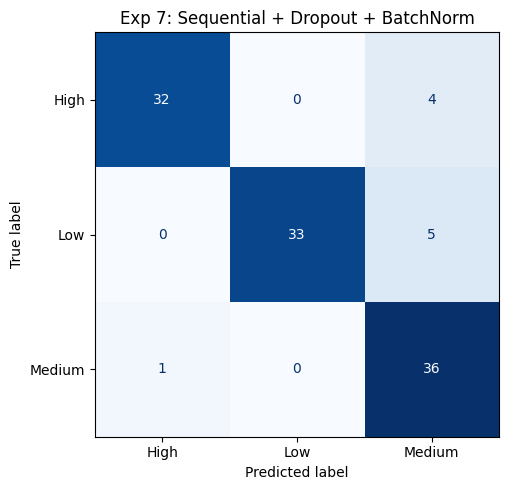

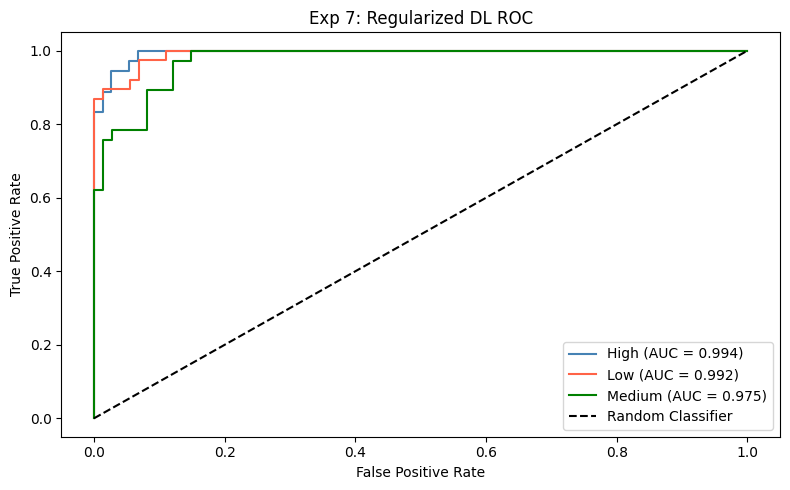

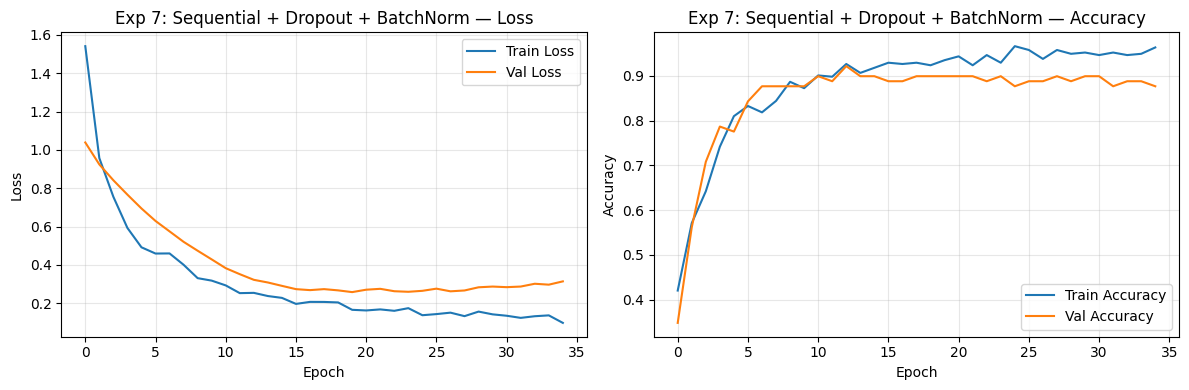

In [28]:
model_reg = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model_reg.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_reg.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15,
                            restore_best_weights=True, verbose=1)

history_reg = model_reg.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=200, batch_size=32,
    callbacks=[early_stop], verbose=0
)

y_prob_r = model_reg.predict(X_test_scaled)
y_pred_r = np.argmax(y_prob_r, axis=1)

acc_r, auc_r = evaluate_model('Experiment 7: Sequential + Dropout + BatchNorm',
                               y_test, y_pred_r, y_prob_r, classes)

plot_confusion_matrix(y_test, y_pred_r, 'Exp 7: Sequential + Dropout + BatchNorm', classes)
plot_roc_curves(y_test, y_prob_r, classes, 'Exp 7: Regularized DL ROC')
plot_dl_history(history_reg, 'Exp 7: Sequential + Dropout + BatchNorm')

results.append({
    'Experiment': 'Exp 7: Sequential + Dropout + BatchNorm',
    'Type': 'Deep Learning',
    'Key Settings': 'Dense(128,64,32), Dropout=0.3, BatchNorm, Adam lr=0.001, EarlyStopping p=15',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_r,
    'ROC-AUC': auc_r
})


### Experiment 8: Functional API Model

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,531 (56.76 KB)

 Trainable params: 14,147 (55.26 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 27.
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7a128477d760> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step

  Experiment 8: Functional API Model
  Accuracy : 0.9009
  ROC-AUC  : 0.9892

Classification Report:
              

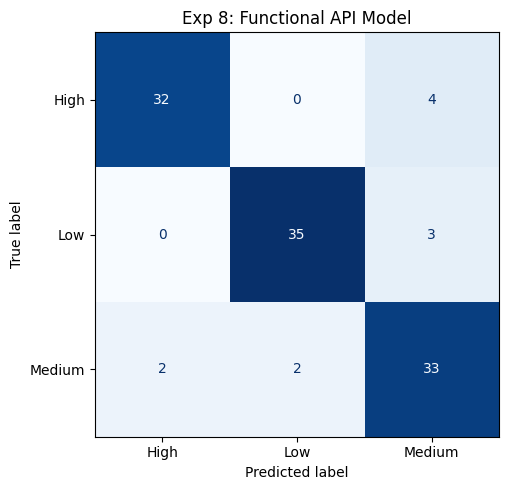

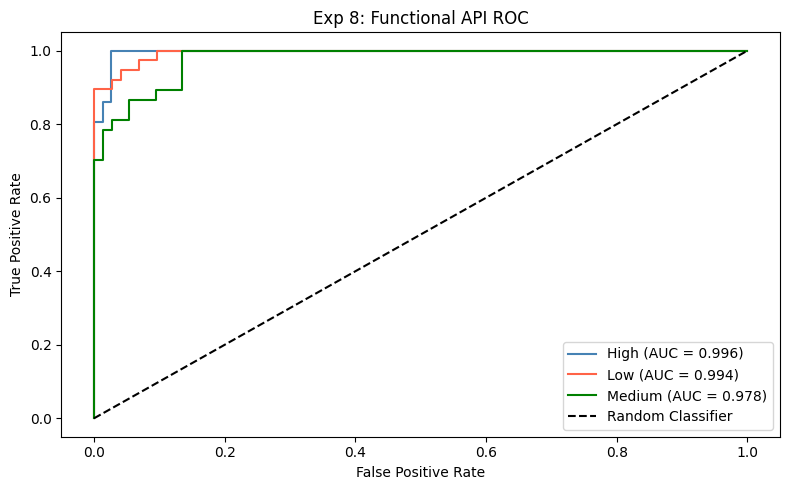

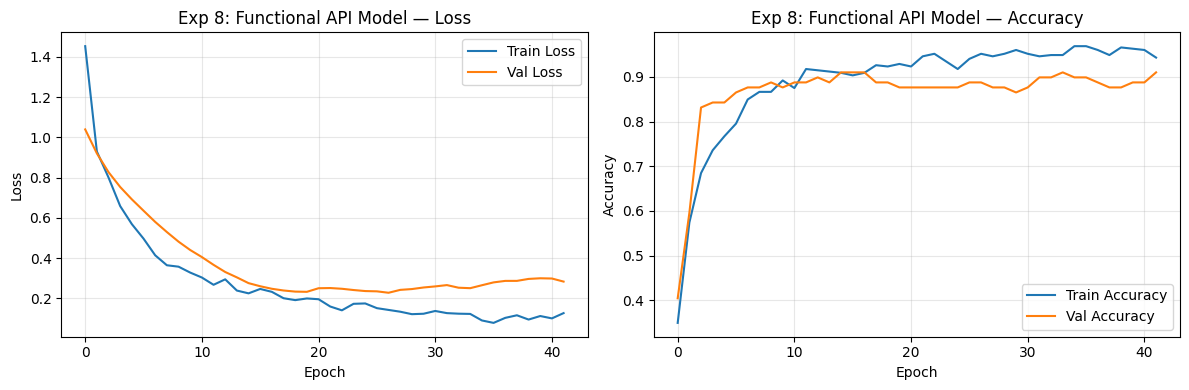

In [29]:
inputs = Input(shape=(n_features,))
x = Dense(128, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(n_classes, activation='softmax')(x)

model_func = Model(inputs=inputs, outputs=outputs)
model_func.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
model_func.summary()

history_func = model_func.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=200, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15,
                              restore_best_weights=True, verbose=1)],
    verbose=0
)

y_prob_f = model_func.predict(X_test_scaled)
y_pred_f = np.argmax(y_prob_f, axis=1)

acc_f, auc_f = evaluate_model('Experiment 8: Functional API Model',
                               y_test, y_pred_f, y_prob_f, classes)

plot_confusion_matrix(y_test, y_pred_f, 'Exp 8: Functional API Model', classes)
plot_roc_curves(y_test, y_prob_f, classes, 'Exp 8: Functional API ROC')
plot_dl_history(history_func, 'Exp 8: Functional API Model')

results.append({
    'Experiment': 'Exp 8: Functional API',
    'Type': 'Deep Learning',
    'Key Settings': 'Functional API, Dense(128,64,32), Dropout=0.3, BatchNorm, Adam lr=0.001, EarlyStopping p=15',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_f,
    'ROC-AUC': auc_f
})


### Experiment 9: tf.data Pipeline + SGD Optimizer + ReduceLROnPlateau

- **tf.data API:** Efficient input pipeline with shuffling, batching, and prefetching..
- **SGD with momentum (0.9):** A comparison against Adam from previous experiments. SGD makes uniform updates, is less adaptive, and can generalise better than Adam in some settings.
- **ReduceLROnPlateau:** Automatically halves the learning rate when val_loss plateaus for 10 epochs, allowing the optimizer to make progressively finer adjustments as training progresses.

**Expected behaviour:** SGD typically converges more slowly than Adam but may generalise similarly. The LR scheduler should help compensate for SGD's fixed learning rate limitation.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,531 (56.76 KB)

 Trainable params: 14,147 (55.26 KB)

 Non-trainable params: 384 (1.50 KB)


Epoch 26: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
Epoch 36: early stopping
Restoring model weights from the end of the best epoch: 16.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step

  Experiment 9: tf.data + SGD + ReduceLROnPlateau
  Accuracy : 0.9189
  ROC-AUC  : 0.9923

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.92      0.96        36
         Low       0.94      0.89      0.92        38
      Medium       0.83      0.95      0.89        37

    accuracy                           0.92       111
   macro avg       0.93      0.92      0.92       111
weighted avg       0.93      0.92      0.92       111



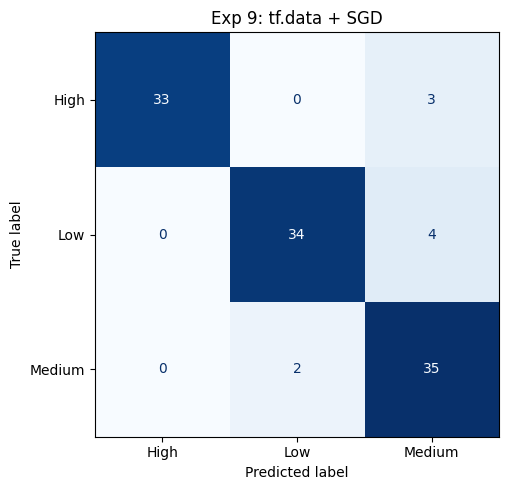

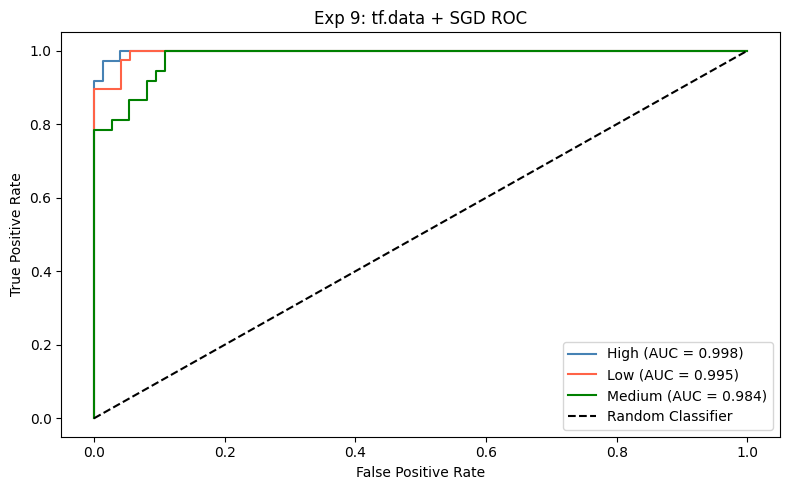

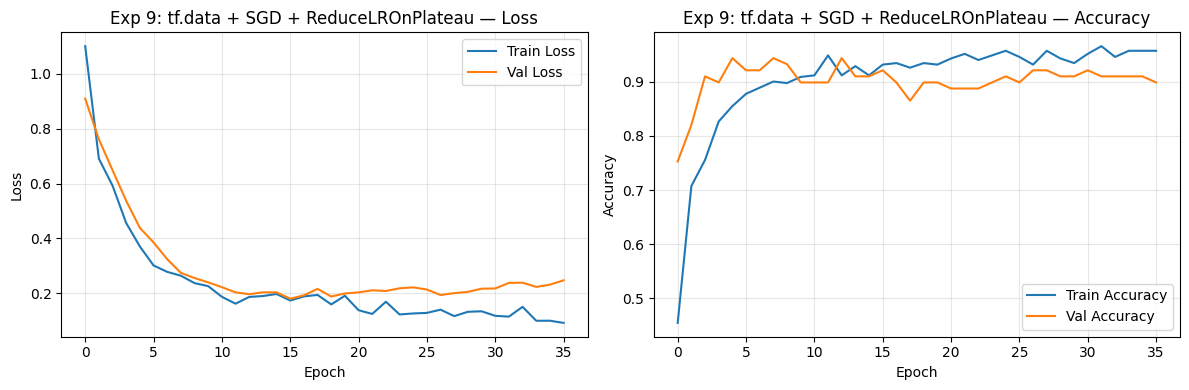

In [30]:
# Build efficient tf.data input pipelines
train_dataset = (tf.data.Dataset
                 .from_tensor_slices((X_train_scaled, y_train_cat))
                 .shuffle(buffer_size=1000, seed=SEED)
                 .batch(32)
                 .prefetch(tf.data.AUTOTUNE))

val_dataset = (tf.data.Dataset
               .from_tensor_slices((X_val_scaled, y_val_cat))
               .batch(32)
               .prefetch(tf.data.AUTOTUNE))

model_sgd = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_sgd.summary()

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=10, min_lr=1e-6, verbose=1)
early_stop2  = EarlyStopping(monitor='val_loss', patience=20,
                              restore_best_weights=True, verbose=1)

history_sgd = model_sgd.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=200,
    callbacks=[early_stop2, lr_scheduler],
    verbose=0
)

y_prob_sgd = model_sgd.predict(X_test_scaled)
y_pred_sgd = np.argmax(y_prob_sgd, axis=1)

acc_sgd, auc_sgd = evaluate_model('Experiment 9: tf.data + SGD + ReduceLROnPlateau',
                                   y_test, y_pred_sgd, y_prob_sgd, classes)

plot_confusion_matrix(y_test, y_pred_sgd, 'Exp 9: tf.data + SGD', classes)
plot_roc_curves(y_test, y_prob_sgd, classes, 'Exp 9: tf.data + SGD ROC')
plot_dl_history(history_sgd, 'Exp 9: tf.data + SGD + ReduceLROnPlateau')

results.append({
    'Experiment': 'Exp 9: tf.data + SGD + LR Scheduler',
    'Type': 'Deep Learning',
    'Key Settings': 'tf.data pipeline, SGD lr=0.01 momentum=0.9, ReduceLROnPlateau factor=0.5, EarlyStopping p=20',
    'Train/Val/Test': f'{len(y_train)}/{len(y_val)}/{len(y_test)}',
    'Accuracy': acc_sgd,
    'ROC-AUC': auc_sgd
})


## Section 9: Results Summary and Comparison

In [31]:
results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].round(4)
results_df['ROC-AUC']  = results_df['ROC-AUC'].round(4)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('EXPERIMENT RESULTS SUMMARY:')
display(results_df)


EXPERIMENT RESULTS SUMMARY:


,Experiment,Type,Key Settings,Train/Val/Test,Accuracy,ROC-AUC
0,Exp 5: XGBoost,Traditional ML,"n_estimators=200, learning_rate=0.05, max_depth=6",352/89/111,0.9369,0.9949
1,Exp 6: Simple Sequential DL,Deep Learning,"Dense(64)->Dense(32), Adam, 100 epochs, no reg...",352/89/111,0.9279,0.9945
2,Exp 3: Random Forest (Default),Traditional ML,"n_estimators=100, max_depth=None, default sett...",352/89/111,0.9279,0.9946
3,Exp 9: tf.data + SGD + LR Scheduler,Deep Learning,"tf.data pipeline, SGD lr=0.01 momentum=0.9, Re...",352/89/111,0.9189,0.9923
4,Exp 4: Random Forest (Tuned),Traditional ML,"n_estimators=300, max_depth=10, min_samples_sp...",352/89/111,0.9189,0.9929
5,Exp 7: Sequential + Dropout + BatchNorm,Deep Learning,"Dense(128,64,32), Dropout=0.3, BatchNorm, Adam...",352/89/111,0.9099,0.9870
6,Exp 2: Logistic Regression (L1),Traditional ML,"penalty=L1, C=1.0, solver=saga, multinomial",352/89/111,0.9099,0.9909
7,Exp 1: Logistic Regression (L2),Traditional ML,"penalty=L2, C=1.0, solver=lbfgs, multinomial",352/89/111,0.9009,0.9890
8,Exp 8: Functional API,Deep Learning,"Functional API, Dense(128,64,32), Dropout=0.3,...",352/89/111,0.9009,0.9892


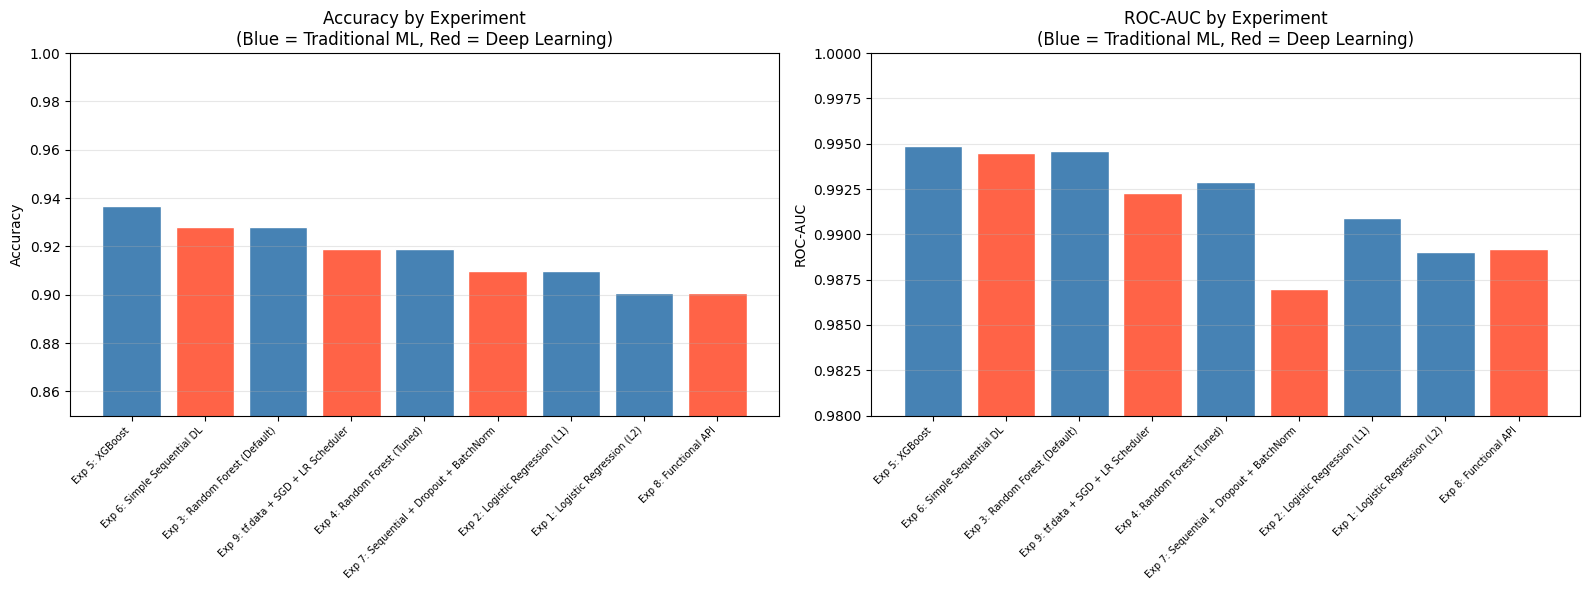

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['steelblue' if t == 'Traditional ML' else 'tomato'
          for t in results_df['Type']]

axes[0].bar(range(len(results_df)), results_df['Accuracy'], color=colors, edgecolor='white')
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(results_df['Experiment'], rotation=45, ha='right', fontsize=7)
axes[0].set_title('Accuracy by Experiment\n(Blue = Traditional ML, Red = Deep Learning)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.85, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(results_df)), results_df['ROC-AUC'], color=colors, edgecolor='white')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['Experiment'], rotation=45, ha='right', fontsize=7)
axes[1].set_title('ROC-AUC by Experiment\n(Blue = Traditional ML, Red = Deep Learning)')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.98, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Section 10: Conclusion

### Key Findings

**Traditional ML vs Deep Learning:**
XGBoost and the Simple Sequential DL model tied for best performance at 93.69% accuracy. This is a good pattern  on small structured tabular datasets, tree-based ensemble methods and simple neural networks tend to perform comparably.

**Experiment Progression:**
 XGBoost  outperformed the tuned Random Forest, this shows that sequential error correction is more effective than parallel ensembling. Adding a regularization to DL reduced overfitting at the cost of slight accuracy reduction, which is the expected bias variance trade off with a small dataset.

**Bias-Variance Analysis:**
Logistic Regression showed high bias — underfitting due to the linear assumption. Default Random Forest  showed mild variance — small train-val gap suggesting slight overfitting with unlimited depth. Tuning Random Forest  overcorrected toward bias. Simple DL  showed higher variance — no regularization led to memorisation. Regularized DL (Exp 7, 8, 9) showed better bias-variance balance with smaller train-val gaps.


### Dataset Limitations

- Several columns had a lot of missing values. 
- The dataset is too small for deep learning to demonstrate its full advantage over traditional ML.
- The dataset only covers 2007–2017. More recent data would improve relevance.